In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split

In [2]:
PATH = "../data/raw/listings.csv"
df_airbnb = pd.read_csv(PATH)

# Display all the columns
pd.set_option('display.max_columns', None)

In [3]:
df_airbnb.shape

(6334, 79)

In [4]:
df_airbnb.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,132068,https://www.airbnb.com/rooms/132068,20250929230956,2025-09-30,city scrape,Great attic+terrace+parking. Beach views. ESS0...,"Amazing modern, clean & fully equiped flat of...",Gros is the trendy neighborhood of Donosti. Th...,https://a0.muscache.com/pictures/hosting/Hosti...,648938,https://www.airbnb.com/users/show/648938,Mikel,2011-05-31,"San Sebastian, Spain",Nací y crecí en San Sebastian. Al igual que vo...,within an hour,100%,100%,t,https://a0.muscache.com/im/users/648938/profil...,https://a0.muscache.com/im/users/648938/profil...,NaN,1.0,1.0,"['email', 'phone']",t,t,"Donostia-San Sebastian, Basque Country, Spain",Donostia-San SebastiÃ¡n,GuipÃºzcoa,43.324750,-1.973350,Entire condo,Entire home/apt,4,1.0,1 bath,2.0,3.0,"[""Refrigerator"", ""Microwave"", ""Essentials"", ""W...",$201.00,1,63,1.0,2.0,63.0,63.0,1.8,63.0,NaN,t,2,16,34,273,2025-09-30,818,69,6,37,67,255,51255.0,2011-06-04,2025-09-28,4.89,4.90,4.78,4.97,4.97,4.94,4.76,ESFCTU00002000700022477500000000000000000000ES...,t,1,1,0,0,4.69
1,225692,https://www.airbnb.com/rooms/225692,20250929230956,2025-09-30,city scrape,"Parte Vieja, San Sebastian",NaN,NaN,https://a0.muscache.com/pictures/31866298/de9d...,1176053,https://www.airbnb.com/users/show/1176053,Julia,2011-09-18,"San Sebastian, Spain","Hola, soy Julia, el de la foto es mi pequeño t...",within a few hours,100%,94%,t,https://a0.muscache.com/im/users/1176053/profi...,https://a0.muscache.com/im/users/1176053/profi...,NaN,1.0,1.0,"['email', 'phone']",t,t,NaN,Donostia-San SebastiÃ¡n,GuipÃºzcoa,43.324942,-1.982063,Entire rental unit,Entire home/apt,6,1.0,1 bath,3.0,4.0,"[""Pack \u2019n play/Travel crib"", ""Refrigerato...",$173.00,2,365,2.0,3.0,365.0,365.0,2.3,365.0,NaN,t,13,18,18,147,2025-09-30,293,25,0,18,30,150,25950.0,2011-10-12,2025-08-22,4.83,4.87,4.90,4.89,4.93,4.95,4.77,ESS00994,f,1,1,0,0,1.72
2,309812,https://www.airbnb.com/rooms/309812,20250929230956,2025-09-30,city scrape,Impresionante vivienda céntrica con vistas al mar,NaN,The apartment is located in the Romantic Area ...,https://a0.muscache.com/pictures/50826406/0c15...,1589633,https://www.airbnb.com/users/show/1589633,Emy,2012-01-10,"San Sebastian, Spain",My name is Emy and I am the owner of these apa...,within a few hours,100%,100%,f,https://a0.muscache.com/im/users/1589633/profi...,https://a0.muscache.com/im/users/1589633/profi...,NaN,7.0,8.0,"['email', 'phone']",t,t,"Donostia-San Sebastian, Basque Country, Spain",Donostia-San SebastiÃ¡n,GuipÃºzcoa,43.316630,-1.986160,Entire rental unit,Entire home/apt,8,2.0,2 baths,3.0,5.0,"[""Pack \u2019n play/Travel crib"", 

In [5]:
df_airbnb.info()

<class 'pandas.DataFrame'>
RangeIndex: 6334 entries, 0 to 6333
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            6334 non-null   int64  
 1   listing_url                                   6334 non-null   str    
 2   scrape_id                                     6334 non-null   int64  
 3   last_scraped                                  6334 non-null   str    
 4   source                                        6334 non-null   str    
 5   name                                          6334 non-null   str    
 6   description                                   6102 non-null   str    
 7   neighborhood_overview                         2941 non-null   str    
 8   picture_url                                   6334 non-null   str    
 9   host_id                                       6334 non-null   int64  
 10 

In [6]:
# Turn the string "price" data into numeric
df_airbnb["price"] = (
    df_airbnb["price"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

In [7]:
# Check for NaN's in the "price" column
df_airbnb["price"].isna().sum()

np.int64(683)

In [8]:
# Drop all the rows whose price value is NaN, imputation is not an option since they're the target values
df_airbnb = df_airbnb.dropna(subset=["price"]).copy()

In [9]:
# Create helper bins (quantiles) for stratified train/test split on price
df_airbnb["price_bin"] = pd.qcut(df_airbnb["price"], q=5, duplicates="drop")

To ensure that the training and test sets contain a similar distribution of listing prices, the **price** variable is discretized into quantile-based bins using **pd.qcut**. This creates a temporary categorical variable (**price_bin**) that groups listings into five equally populated price ranges. These bins are then used to perform a stratified train/test split, preserving the overall price distribution in both subsets.

In [10]:
# Create input and output variables
X = df_airbnb.drop(columns=["price"])
y = df_airbnb["price"]

In [11]:
# Split data into 80% trainig and 20% test sets using stratification on price bins.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=X["price_bin"]
)

**EDA**

In [12]:
# Remove the price bins from each set. 
X_train = X_train.drop(columns=["price_bin"])
X_test = X_test.drop(columns=["price_bin"])

In [13]:
data = X_train.copy()

In [14]:
data.shape

(4520, 78)

In [15]:
data.info()

<class 'pandas.DataFrame'>
Index: 4520 entries, 1592 to 1552
Data columns (total 78 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            4520 non-null   int64  
 1   listing_url                                   4520 non-null   str    
 2   scrape_id                                     4520 non-null   int64  
 3   last_scraped                                  4520 non-null   str    
 4   source                                        4520 non-null   str    
 5   name                                          4520 non-null   str    
 6   description                                   4354 non-null   str    
 7   neighborhood_overview                         2108 non-null   str    
 8   picture_url                                   4520 non-null   str    
 9   host_id                                       4520 non-null   int64  
 10  h

In [16]:
data.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
1592,35556537,https://www.airbnb.com/rooms/35556537,20250929230956,2025-09-30,city scrape,"NUEVO APARTAMENTO, junto CASCO VIEJO",Enjoy a few days in Bilbao in this modern and ...,"Next to Casco Viejo, a fashionable neighborhoo...",https://a0.muscache.com/pictures/30549523-bde0...,267100434,https://www.airbnb.com/users/show/267100434,Lys,2019-06-08,"Bilbao, Spain","Hola, yo seré vuestra anfitriona. \nPara cualq...",within an hour,100%,100%,t,https://a0.muscache.com/im/pictures/user/938b4...,https://a0.muscache.com/im/pictures/user/938b4...,NaN,1.0,1.0,"['email', 'phone']",t,t,"Bilbao, Vizkaia, Spain, Spain",Bilbao,Vizcaya,43.256507,-2.928715,Entire rental unit,Entire home/apt,4,1.0,1 bath,2.0,3.0,"[""Pack \u2019n play/Travel crib"", ""Refrigerato...",1,1125,1.0,3.0,1125.0,1125.0,1.3,1125.0,NaN,t,7,29,59,149,2025-09-30,359,71,5,62,73,255,31365.0,2019-06-15,2025-09-24,4.91,4.95,4.98,4.97,4.99,4.60,4.80,ESFCTU00004802700084705300000000000000000000EB...,f,1,1,0,0,4.68
1382,31667896,https://www.airbnb.com/rooms/31667896,20250929230956,2025-09-30,city scrape,Apartamento nuevo en el centro de San Sebastián,Apartment in the center of San Sebastian for ...,"Located in the old part, in the heart of San S...",https://a0.muscache.com/pictures/3176ad0f-4ba1...,133395812,https://www.airbnb.com/users/show/133395812,Jaione,2017-06-04,"San Sebastián, Spain","Emprendedora, sociable, creativa e inquieta. M...",within a few hours,90%,96%,f,https://a0.muscache.com/im/pictures/user/4a4e0...,https://a0.muscache.com/im/pictures/user/4a4e0...,NaN,10.0,10.0,"['email', 'phone']",t,t,"Donostia-San Sebastian, Euskadi, Spain",Donostia-San SebastiÃ¡n,GuipÃºzcoa,43.324610,-1.984080,Entire rental unit,Entire home/apt,4,1.0,1 bath,3.0,4.0,"[""Refrigerator"", ""Microwave"", ""Hot water kettl...",30,300,30.0,30.0,300.0,300.0,30.0,300.0,NaN,t,25,50,76,287,2025-09-30,5,2,0,79,1,120,13800.0,2019-06-30,2025-07-31,5.00,5.00,5.00,5.00,5.00,4.80,4.60,ESFCNT0000200080002542430000000000000000000000...,f,10,10,0,0,0.07
2536,50127094,https://www.airbnb.com/rooms/50127094,20250929230956,2025-09-30,city scrape,Boulevard Suite: 2 min from La Concha Beach,UNBEATABLE LOCATION! This flat is the perfect ...,"Right in the Boulevard de San Sebastian, the h...",https://a0.muscache.com/pictures/miso/Hosting-...,2470030,https://www.airbnb.com/users/show/2470030,Javier,2012-05-26,"San Sebastián, Spain","BIENVENIDO, ONGI ETORRI, WELLCOME! \n\nWe are ...",within an hour,100%,97%,t,https://a0.muscache.com/im/pictures/user/User/...,https://a0.muscache.com/im/pictures/user/User/...,NaN,27.0,33.0,"['email', 'phon

In [17]:
# Check missing values per column in percentage with a descending order
missing_percentage = data.isna().mean().mul(100).sort_values(ascending=False)
missing_percentage[missing_percentage > 0]

calendar_updated               100.000000
host_neighbourhood              94.955752
neighborhood_overview           53.362832
neighbourhood                   53.362832
host_about                      52.743363
host_location                   28.296460
license                         18.539823
last_review                      9.336283
first_review                     9.336283
review_scores_location           9.336283
review_scores_accuracy           9.336283
reviews_per_month                9.336283
review_scores_value              9.336283
review_scores_cleanliness        9.336283
review_scores_communication      9.336283
review_scores_checkin            9.336283
review_scores_rating             9.336283
host_response_rate               7.743363
host_response_time               7.743363
host_acceptance_rate             4.823009
description                      3.672566
host_is_superhost                2.898230
has_availability                 0.575221
beds                             0

In [18]:
# Drop columns that'll never be used in modeling such as the ones with too many missing values,
# the ones with too many unique values, 
# and the ones that are not relevant to the target variable.

cols_to_drop = [
    "id",
    "listing_url",
    "scrape_id",
    "last_scraped",
    "source",
    "name",
    "description",
    "neighborhood_overview",
    "picture_url",
    "host_id",
    "host_url",
    "host_thumbnail_url",
    "host_picture_url",
    "host_about",
    "host_neighbourhood",
    "neighbourhood",
    "calendar_updated",
    "calendar_last_scraped",
    "license",
    "estimated_revenue_l365d",
    "estimated_occupancy_l365d",
    "calculated_host_listings_count",
    "minimum_minimum_nights",
    "maximum_minimum_nights",
    "minimum_maximum_nights",
    "maximum_maximum_nights",
    "minimum_nights_avg_ntm",
    "maximum_nights_avg_ntm",
    "availability_60",
    "availability_90",
    "availability_eoy",
    "number_of_reviews",
    "number_of_reviews_ltm",
    "number_of_reviews_ly",
    "number_of_reviews_l30d",
    "review_scores_accuracy",
    "review_scores_checkin",
    "review_scores_communication",
    "review_scores_value",
    "calculated_host_listings_count_entire_homes",
    "calculated_host_listings_count_private_rooms",
    "calculated_host_listings_count_shared_rooms",
    "host_total_listings_count",
]

data = data.drop(columns=cols_to_drop)


In [19]:
data.describe()

,host_listings_count,latitude,longitude,accommodates,bathrooms,bedrooms,beds,minimum_nights,maximum_nights,availability_30,availability_365,review_scores_rating,review_scores_cleanliness,review_scores_location,reviews_per_month
count,4518.000000,4520.000000,4520.000000,4520.000000,4516.000000,4518.000000,4509.000000,4520.000000,4.520000e+03,4520.000000,4520.000000,4098.000000,4098.000000,4098.000000,4098.000000
mean,21.817176,43.260544,-2.510491,4.043805,1.518379,1.992917,3.017964,3.103540,2.290641e+04,15.152434,203.566593,4.749219,4.774156,4.744287,1.549048
std,84.068742,0.151415,0.435468,2.342981,1.019356,1.271072,2.362151,7.113805,1.487473e+06,9.812605,119.513660,0.322975,0.308285,0.330174,1.829270
min,1.000000,42.487640,-3.378762,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000e+00,0.000000,0.000000,1.000000,1.000000,1.000000,0.010000
25%,1.000000,43.257148,-2.925680,2.000000,1.000000,1.000000,1.000000,1.000000,1.800000e+02,7.000000,86.000000,4.670000,4.700000,4.660000,0.440000
50%,3.000000,43.299497,-2.670280,4.000000,1.000000,2.000000,3.000000,2.000000,3.650000e+02,15.000000,219.500000,4.830000,4.860000,4.830000,1.000000
75%,10.000000,43.323660,-1.985796,5.000000,2.000000,3.000000,4.000000,2.000000,1.125000e+03,24.000000,322.000000,4.940000,4.960000,4.950000,2.110000
max,967.000000,43.441490,-1.757010,16.000000,24.000000,25.000000,48.000000,160.000000,1.000000e+08,30.000000,365.000000,5.000000,5.000000,5.000000,47.610000


In [20]:
y_train.describe()

count     4520.000000
mean       209.796239
std        602.983507
min         16.000000
25%         88.000000
50%        129.000000
75%        199.000000
max      14362.000000
Name: price, dtype: float64

The price data is right-skewed, there are outliers which can distort the model, so we may try to apply log transformation on prices to make the distribution more balanced. 

<Axes: >

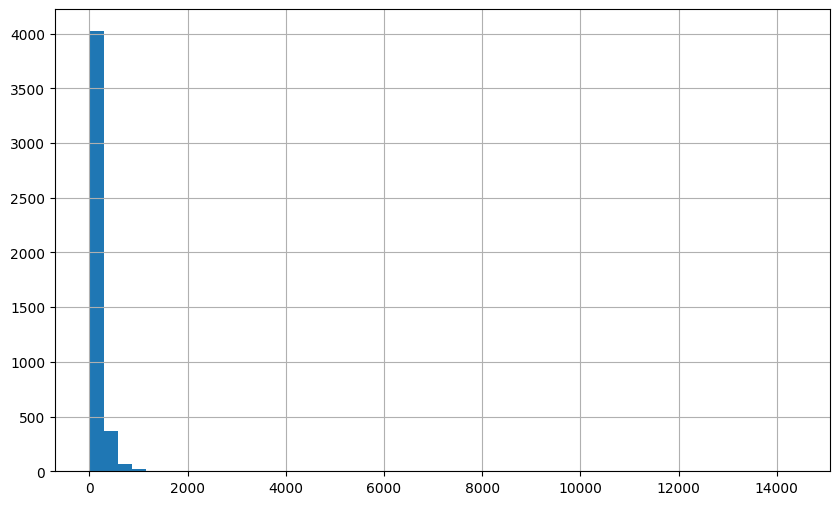

In [21]:
# Check the distribution of the target variable with a histogram. It's right-skewed, so we can apply log transformation to make it more normal.
y_train.hist(bins=50, figsize=(10, 6))

<Axes: >

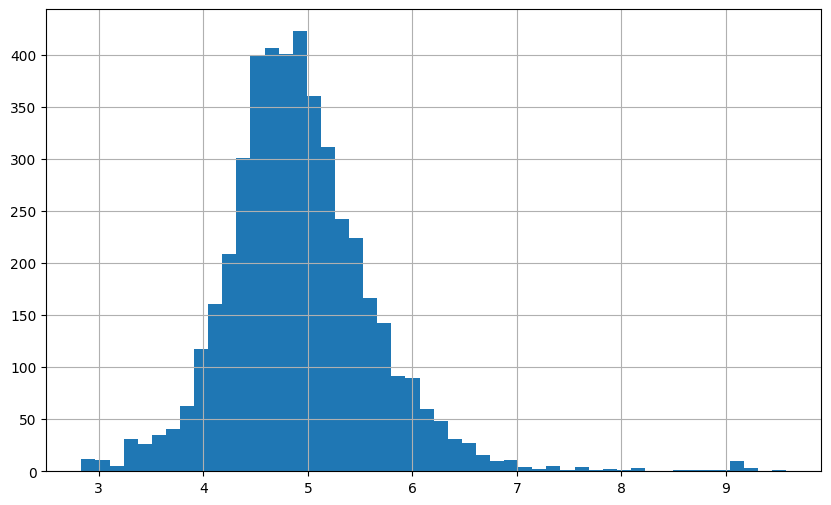

In [22]:
# Check the target variable with a histogram after log transformation. It's more normal now.
np.log1p(y_train).hist(bins=50, figsize=(10, 6))

As we can see, the large values are compressed, skewness reduced and the price data is more normal now.

In [23]:
numeric_cols = data.select_dtypes(include="number").columns
numeric_cols

Index(['host_listings_count', 'latitude', 'longitude', 'accommodates',
       'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'maximum_nights',
       'availability_30', 'availability_365', 'review_scores_rating',
       'review_scores_cleanliness', 'review_scores_location',
       'reviews_per_month'],
      dtype='str')

In [24]:
corr = data[numeric_cols].corrwith(np.log1p(y_train)).sort_values(ascending=False)
corr

accommodates                 0.522479
bedrooms                     0.453369
beds                         0.417159
bathrooms                    0.370313
host_listings_count          0.289521
review_scores_location       0.199290
longitude                    0.194356
review_scores_rating         0.126988
availability_365             0.118792
review_scores_cleanliness    0.112547
availability_30              0.074839
latitude                     0.061488
maximum_nights              -0.000511
minimum_nights              -0.063377
reviews_per_month           -0.139794
dtype: float64

array([[<Axes: title={'center': 'host_listings_count'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'accommodates'}>],
       [<Axes: title={'center': 'bathrooms'}>,
        <Axes: title={'center': 'bedrooms'}>,
        <Axes: title={'center': 'beds'}>,
        <Axes: title={'center': 'minimum_nights'}>],
       [<Axes: title={'center': 'maximum_nights'}>,
        <Axes: title={'center': 'availability_30'}>,
        <Axes: title={'center': 'availability_365'}>,
        <Axes: title={'center': 'review_scores_rating'}>],
       [<Axes: title={'center': 'review_scores_cleanliness'}>,
        <Axes: title={'center': 'review_scores_location'}>,
        <Axes: title={'center': 'reviews_per_month'}>,
        <Axes: title={'center': 'price'}>]], dtype=object)

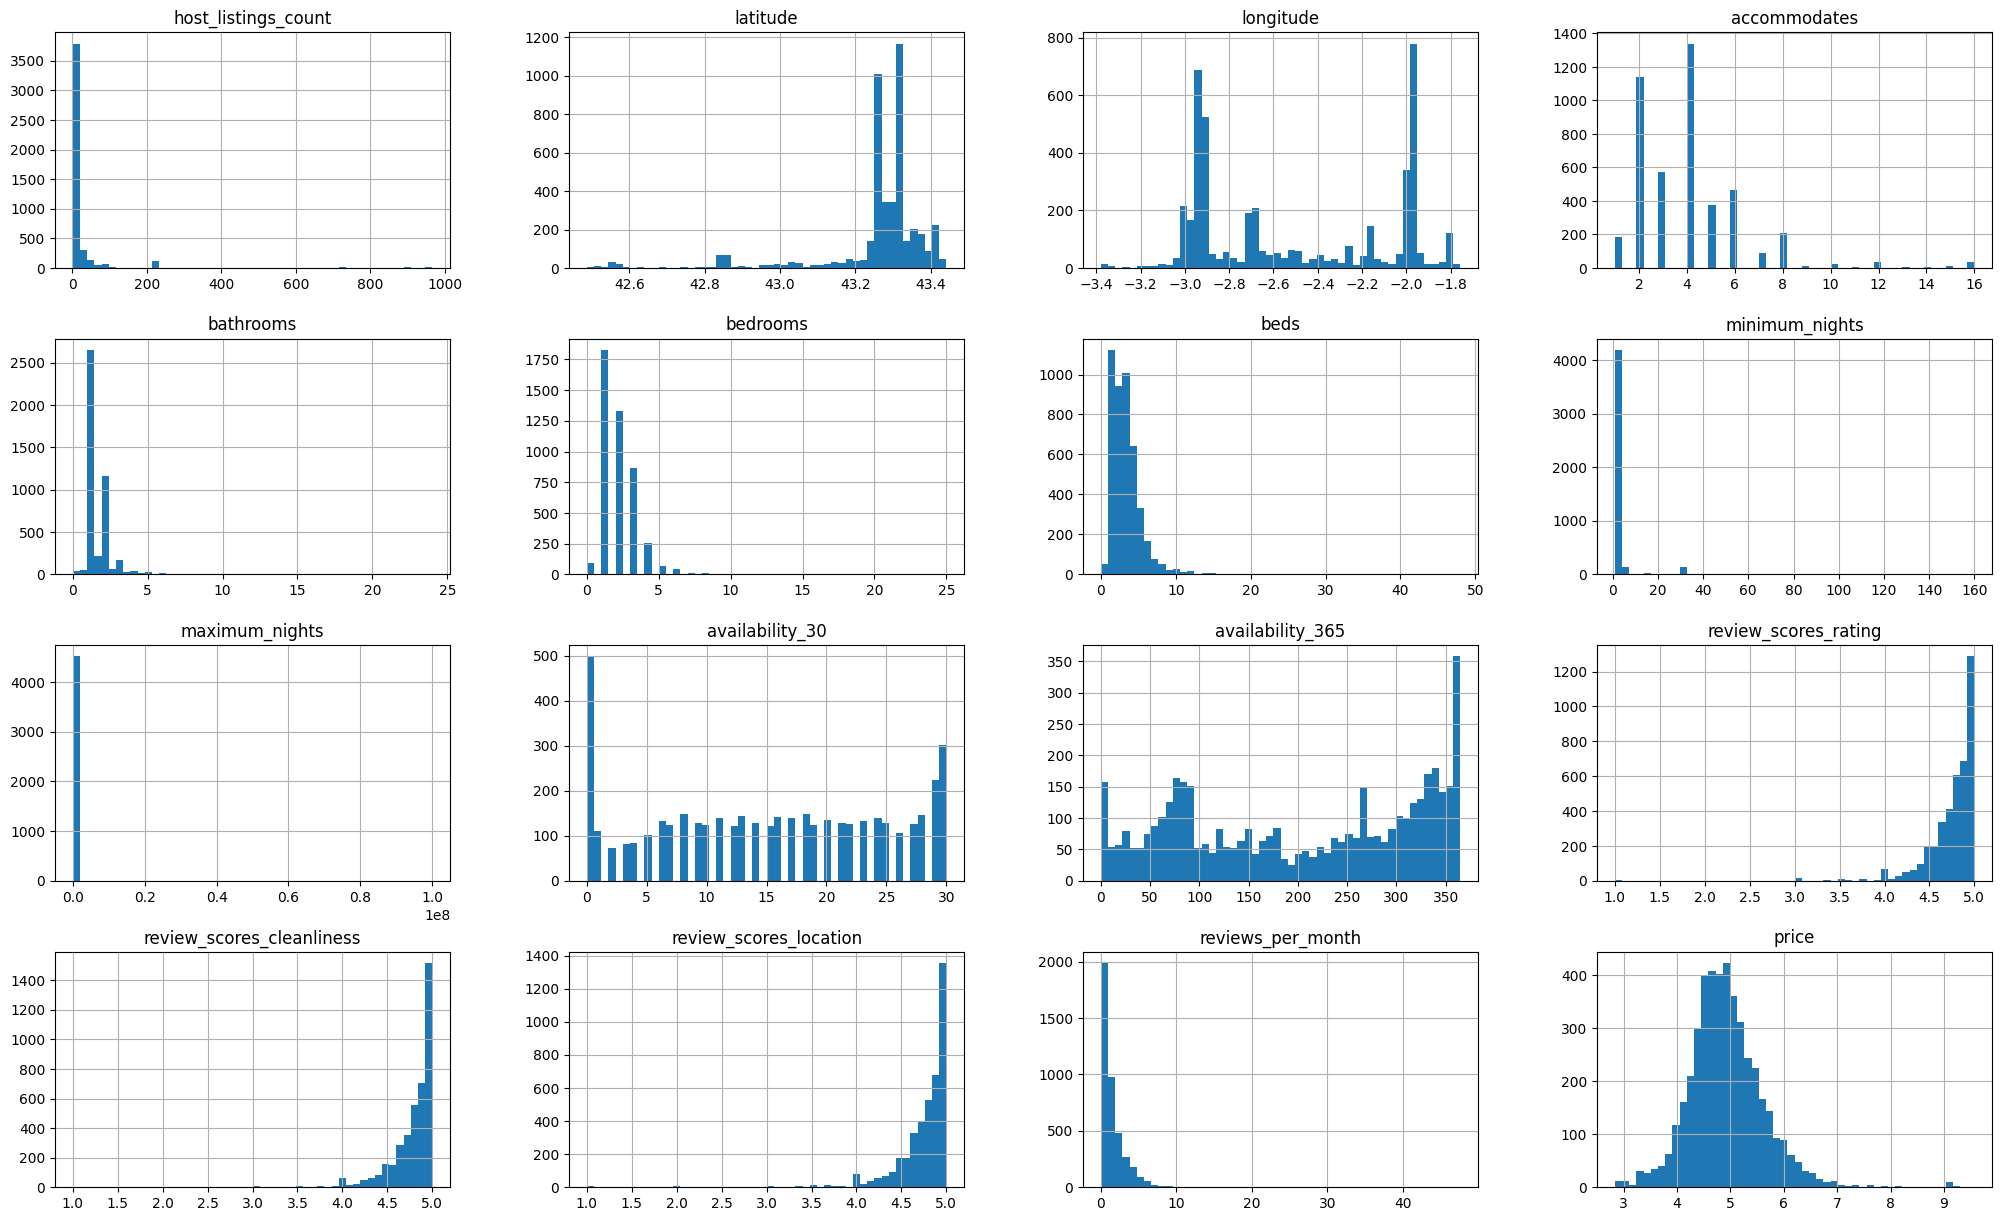

In [25]:
# Create histograms for the selected numeric columns and the target variable

combined = pd.concat([data[numeric_cols], np.log1p(y_train)], axis=1)

combined.hist(
    bins=50,
    figsize=(25,15),
    grid=True
)

<Axes: >

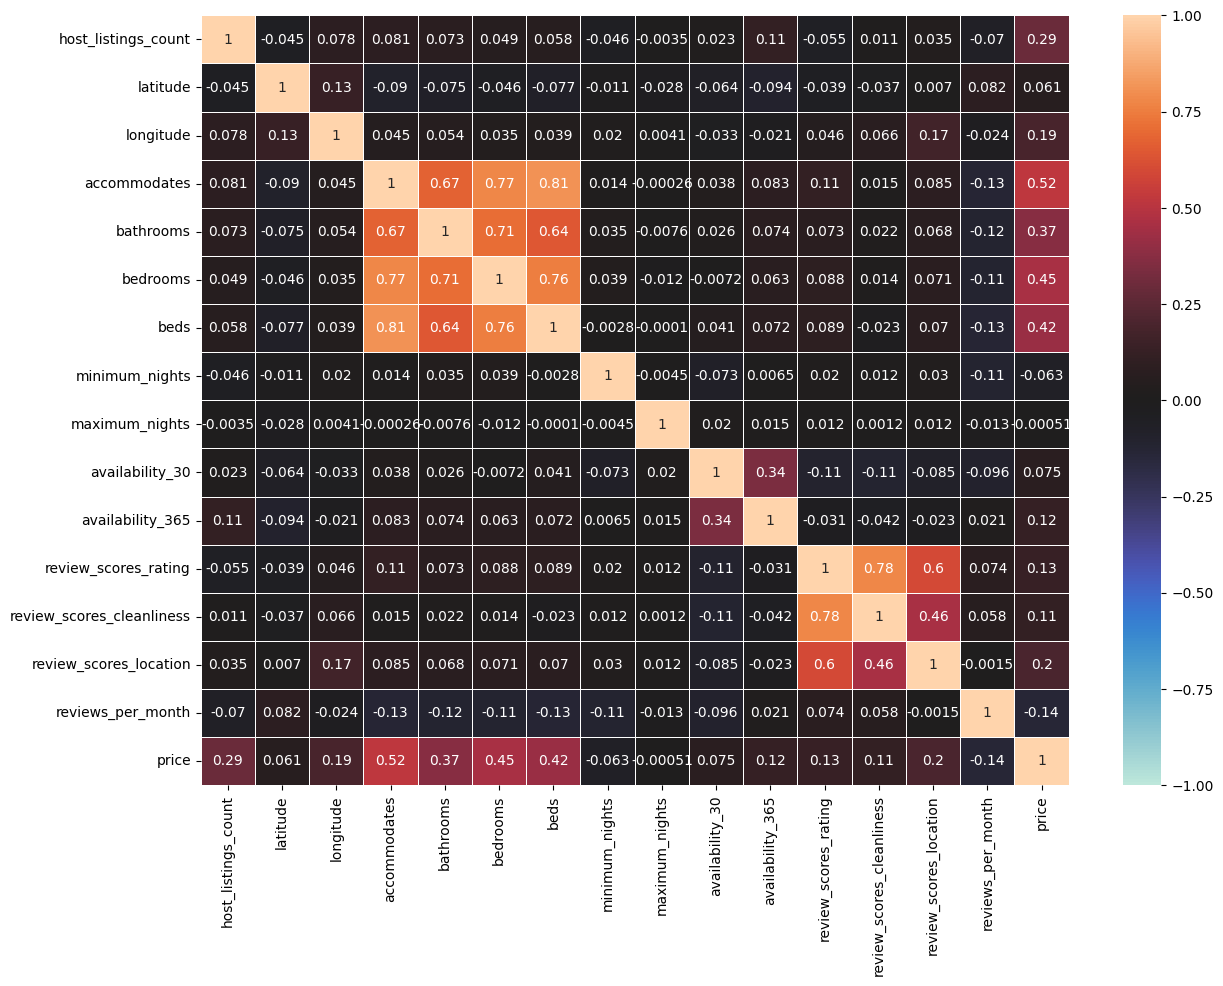

In [26]:
plt.figure(figsize=(14, 10))
sns.heatmap(
    combined.corr(),
    vmin=-1, 
    vmax=1,
    center=0,
    annot=True,   
    linewidths=0.5,
    cbar=True
)

Certain features are highly correlated with each other, later we may use Ridge Regression to deal with the multicollinearity. 

In [27]:
data['bedrooms_per_accommodates'] = data['bedrooms'] / data['accommodates']
data['beds_per_accommodates'] = data['beds'] / data['accommodates']
data['bathrooms_per_accommodates'] = data['bathrooms'] / data['accommodates']
data['reviews_per_accommodates'] = data['reviews_per_month'] / data['accommodates']

In [28]:
data[['bedrooms_per_accommodates', 'beds_per_accommodates', 'bathrooms_per_accommodates', 'reviews_per_accommodates',]].describe()

,bedrooms_per_accommodates,beds_per_accommodates,bathrooms_per_accommodates,reviews_per_accommodates
count,4518.000000,4509.000000,4516.000000,4098.000000
mean,0.523003,0.744490,0.434332,0.526478
std,0.440928,0.498105,0.448474,0.848664
min,0.000000,0.000000,0.000000,0.000625
25%,0.500000,0.500000,0.250000,0.105250
50%,0.500000,0.750000,0.375000,0.260000
75%,0.500000,1.000000,0.500000,0.648563
max,25.000000,25.000000,24.000000,23.805000


In [29]:
new_features = [
    'bedrooms_per_accommodates', 
    'beds_per_accommodates', 
    'bathrooms_per_accommodates', 
    'reviews_per_accommodates',
]

all_numeric_cols = list(numeric_cols) + new_features

corr_2 = data[all_numeric_cols].corrwith(np.log1p(y_train)).sort_values(ascending=False)
corr_2

accommodates                  0.522479
bedrooms                      0.453369
beds                          0.417159
bathrooms                     0.370313
host_listings_count           0.289521
review_scores_location        0.199290
longitude                     0.194356
review_scores_rating          0.126988
availability_365              0.118792
review_scores_cleanliness     0.112547
availability_30               0.074839
latitude                      0.061488
maximum_nights               -0.000511
beds_per_accommodates        -0.024405
minimum_nights               -0.063377
bedrooms_per_accommodates    -0.078419
reviews_per_month            -0.139794
bathrooms_per_accommodates   -0.174476
reviews_per_accommodates     -0.281934
dtype: float64

reviews_per_month is more correlated with the price than the reviews_per_month, so we are going to keep this new feature but drop the others. 

In [30]:
data.columns

Index(['host_name', 'host_since', 'host_location', 'host_response_time',
       'host_response_rate', 'host_acceptance_rate', 'host_is_superhost',
       'host_listings_count', 'host_verifications', 'host_has_profile_pic',
       'host_identity_verified', 'neighbourhood_cleansed',
       'neighbourhood_group_cleansed', 'latitude', 'longitude',
       'property_type', 'room_type', 'accommodates', 'bathrooms',
       'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'minimum_nights',
       'maximum_nights', 'has_availability', 'availability_30',
       'availability_365', 'first_review', 'last_review',
       'review_scores_rating', 'review_scores_cleanliness',
       'review_scores_location', 'instant_bookable', 'reviews_per_month',
       'bedrooms_per_accommodates', 'beds_per_accommodates',
       'bathrooms_per_accommodates', 'reviews_per_accommodates'],
      dtype='str')